Basic Data Processing...

In [1]:
import pandas as pd
sheets = pd.read_excel("./datasets/Scats Data October 2006.xls", sheet_name=None)

removed_days = sheets["Notes"]["Unnamed: 1"].dropna().to_list()[5:]
removed_days = [int(i) for i in removed_days]
# removed_days

df_info = sheets["Summary Of Data"].loc[2:]
df_info.columns = df_info.iloc[0]
df_info = df_info[1:]
df_info["SCATS Number"] = df_info["SCATS Number"].ffill()

df_info.dropna(axis=1, inplace=True)
df_info = df_info.convert_dtypes().infer_objects()
df_info.head(15)

df_info_filtered = df_info[df_info["Total"].between(7, 31)]
df_info_filtered

2,SCATS Number,Location,Total
3,0970,HIGH STREET_RD E of WARRIGAL_RD,31
4,0970,HIGH STREET_RD W of WARRIGAL_RD,30
5,0970,WARRIGAL_RD N of HIGH STREET_RD,31
6,0970,WARRIGAL_RD S of HIGH STREET_RD,31
7,2000,BURWOOD_HWY E of WARRIGAL_RD,29
...,...,...,...
137,4812,SWAN_ST SW of MADDEN_GV,26
138,4821,BURNLEY_ST S OF VICTORIA_ST,31
139,4821,VICTORIA_ST E OF BURNLEY_ST,31
140,4821,VICTORIA_ST W OF BURNLEY_ST,31


We create an identifier for each location: SCATS Number + HF Vicroads Internal

In [2]:

# imagine having good formatting
df = sheets["Data"]
df.columns = pd.Series(df.loc[0])
df = df.loc[1:]

# remove added time
df.loc[:, 'Date'] = pd.to_datetime(df['Date']).dt.date
df = df.convert_dtypes()

# filter good locations
df = df.loc[df["Location"].isin(df_info_filtered["Location"])]

# add location identifier: SCARS Number + VicRoads Internal
df.loc[:, "Identifier"] = df["SCATS Number"].astype(str) + " - " + df["HF VicRoads Internal"].astype(str)
df.columns = df.columns.str.strip()


df.head(10)


,SCATS Number,Location,CD_MELWAY,NB_LATITUDE,NB_LONGITUDE,HF VicRoads Internal,VR Internal Stat,VR Internal Loc,NB_TYPE_SURVEY,Date,...,V87,V88,V89,V90,V91,V92,V93,V94,V95,Identifier
1,0970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-01,...,97,97,66,81,50,59,47,29,34,0970 - 249
2,0970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-02,...,102,107,114,80,60,62,48,44,26,0970 - 249
3,0970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-03,...,132,114,86,93,90,73,57,29,40,0970 - 249
4,0970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-04,...,113,132,101,113,90,78,66,52,44,0970 - 249
5,0970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-05,...,120,116,113,99,91,61,55,49,36,0970 - 249
6,0970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-06,...,137,135,136,108,120,115,102,74,78,0970 - 249
7,0970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-07,...,153,133,109,140,121,123,115,107,127,0970 - 249
8,0970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-08,...,92,96,82,80,64,64,48,48,43,0970 - 249
9,0970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-09,...,107,111,98,83,69,57,50,25,36,0970 - 249
10,0970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-10,...,131,124,111,112,103,66,50,49,36,0970 - 249


Format: Identifier + columns as timestamps

In [3]:
times_dict = {}
vcols = [f"V{str(i).zfill(2)}" for i in range(96)]
numbered_colnames = list(range(96 * 31))
for col in vcols:
    i = int(col[1:]) if len(col[1:]) > 0 else 0
    t = i * 15 
    h = t // 60 
    m = t % 60
    times_dict[col] = f"{str(h).zfill(2)}:{str(m).zfill(2)}" 
times_dict

{'V00': '00:00',
 'V01': '00:15',
 'V02': '00:30',
 'V03': '00:45',
 'V04': '01:00',
 'V05': '01:15',
 'V06': '01:30',
 'V07': '01:45',
 'V08': '02:00',
 'V09': '02:15',
 'V10': '02:30',
 'V11': '02:45',
 'V12': '03:00',
 'V13': '03:15',
 'V14': '03:30',
 'V15': '03:45',
 'V16': '04:00',
 'V17': '04:15',
 'V18': '04:30',
 'V19': '04:45',
 'V20': '05:00',
 'V21': '05:15',
 'V22': '05:30',
 'V23': '05:45',
 'V24': '06:00',
 'V25': '06:15',
 'V26': '06:30',
 'V27': '06:45',
 'V28': '07:00',
 'V29': '07:15',
 'V30': '07:30',
 'V31': '07:45',
 'V32': '08:00',
 'V33': '08:15',
 'V34': '08:30',
 'V35': '08:45',
 'V36': '09:00',
 'V37': '09:15',
 'V38': '09:30',
 'V39': '09:45',
 'V40': '10:00',
 'V41': '10:15',
 'V42': '10:30',
 'V43': '10:45',
 'V44': '11:00',
 'V45': '11:15',
 'V46': '11:30',
 'V47': '11:45',
 'V48': '12:00',
 'V49': '12:15',
 'V50': '12:30',
 'V51': '12:45',
 'V52': '13:00',
 'V53': '13:15',
 'V54': '13:30',
 'V55': '13:45',
 'V56': '14:00',
 'V57': '14:15',
 'V58': '14:30

In [4]:
import numpy as np
groups = df.groupby(by="Identifier")
df_processed = pd.DataFrame()

# add latitude and longtitude
lat_dict = {}
long_dict = {}
identifiers = []
locations_dict = {}

for id, group in groups:
    # all latitude and longtitude is the same
    lat_dict[id] = group["NB_LATITUDE"].iloc[0]
    long_dict[id] = group["NB_LONGITUDE"].iloc[0]
    locations_dict[id] = group["Location"].iloc[0].upper()
    
    combined = pd.concat([group[c] for c in vcols], ignore_index=True)
    df_processed[id] = combined
    
    # index
    identifiers.append(id)
    

    
# df_processed.fillna(-1, inplace=True)
df_processed = pd.concat([
    df_processed, pd.DataFrame([lat_dict]), pd.DataFrame([long_dict]), pd.DataFrame([locations_dict])
])

# post processing: row = identifier + lat-long for coordinate + flow

df_processed = df_processed.T.copy()
df_processed.columns = [*df_processed.columns[:-3], "lat", "long", "location"]
df_processed["id"] = [str(i).strip() for i in identifiers]
df_processed = df_processed[df_processed["lat"] != 0]

valid_lengths = df_processed[numbered_colnames].notna().sum(axis=1)
min_valid_len = valid_lengths.min()
print("Shortest complete length:", min_valid_len)

df_trimmed = df_processed.drop(labels=[i for i in numbered_colnames if i > min_valid_len], axis=1)
df_trimmed





Shortest complete length: 2112


,0,1,2,3,4,5,6,7,8,9,...,2107,2108,2109,2110,2111,2112,lat,long,location,id
0970 - 10503,92,31,20,32,42,31,87,108,32,29,...,423,361,365,414,380,422,-37.8676,145.09146,WARRIGAL_RD S OF HIGH STREET_RD,0970 - 10503
0970 - 16116,37,10,8,6,10,9,27,40,9,8,...,138,124,173,176,170,148,-37.86735,145.09195,HIGH STREET_RD E OF WARRIGAL_RD,0970 - 16116
0970 - 249,86,32,26,32,40,36,62,116,23,27,...,354,265,277,358,308,348,-37.86703,145.09159,WARRIGAL_RD N OF HIGH STREET_RD,0970 - 249
0970 - 5887,47,15,10,20,16,42,67,23,16,22,...,351,349,383,318,352,214,-37.86723,145.09103,HIGH STREET_RD W OF WARRIGAL_RD,0970 - 5887
2000 - 10505,110,28,23,30,40,38,72,116,32,35,...,211,252,283,290,287,202,-37.85221,145.09425,WARRIGAL_RD S OF BURWOOD_HWY,2000 - 10505
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4812 - 6302,49,16,15,22,14,28,38,47,11,8,...,44,56,46,60,73,67,-37.82859,145.01644,SWAN_ST NE OF MADDEN_GV,4812 - 6302
4821 - -1,0,1,0,3,2,2,0,0,0,0,...,11,9,12,17,5,9,-37.81285,145.00849,WALMER_ST N OF VICTORIA_ST,4821 - -1
4821 - 14527,25,10,7,12,14,11,38,27,9,11,...,153,94,186,162,180,180,-37.81312,145.00844,BURNLEY_ST S OF VICTORIA_ST,4821 - 14527
4821 - 16911,44,14,14,25,23,20,46,55,13,21,...,167,187,152,180,195,212,-37.81293,145.00865,VICTORIA_ST E OF BURNLEY_ST,4821 - 16911


check missing data here

In [20]:
import numpy as np
import pandas as pd

missing_per_sensor = df_processed[numbered_colnames].isna().sum(axis=1)
missing_per_time = df_processed[numbered_colnames].isna().sum(axis=0)

print("Missing per sensor (rows):", missing_per_sensor.describe())
print("Missing per time step (columns):", missing_per_time.describe())


Missing per sensor (rows): count    136.000000
mean      84.000000
std      181.560642
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max      864.000000
dtype: float64
Missing per time step (columns): count    2976.000000
mean        3.838710
std         8.448969
min         0.000000
25%         0.000000
50%         0.000000
75%         2.000000
max        33.000000
dtype: float64


In [5]:
from matplotlib import pyplot as plt 

def count_trailing_nans(row):
    """Count consecutive NaNs from the end of a row (right side)."""
    # Convert to boolean array: True where NaN
    is_na = row.isna().to_numpy()
    
    # Reverse it, count consecutive True from start
    count = 0
    for val in is_na[::-1]:
        if val:
            count += 1
        else:
            break
    return count

a = df_processed[numbered_colnames].apply(count_trailing_nans, axis=1)
print(f"Max: {a.max()}")
print(f"Min: {a.min()}")


Max: 864
Min: 0


In [7]:
import numpy as np
import pandas as pd

numbered_colnames = list(range(96 * 31))
# df_processed[numbered_colnames].astype(float, copy=False)
missing_per_sensor = df_processed[numbered_colnames].isna().sum(axis=1)
missing_per_time = df_processed[numbered_colnames].isna().sum(axis=0)

print("Missing per sensor (rows):", missing_per_sensor.describe())
print("Missing per time step (columns):", missing_per_time.describe())


Missing per sensor (rows): count    136.000000
mean      84.000000
std      181.560642
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max      864.000000
dtype: float64
Missing per time step (columns): count    2976.000000
mean        3.838710
std         8.448969
min         0.000000
25%         0.000000
50%         0.000000
75%         2.000000
max        33.000000
dtype: float64


In [8]:
df_processed.columns

Index([         0,          1,          2,          3,          4,          5,
                6,          7,          8,          9,
       ...
             2970,       2971,       2972,       2973,       2974,       2975,
            'lat',     'long', 'location',       'id'],
      dtype='object', length=2980)

In [9]:
import numpy as np

def count_trailing_nans(row):
    return np.argmax(~np.isnan(row[::-1])) if np.isnan(row).any() else 0

trailing_nans = df_processed[numbered_colnames].apply(count_trailing_nans, axis=0)
print(trailing_nans.describe())


TypeError: ufunc 'isnan' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

In [18]:
from matplotlib import pyplot as plt 
import numpy as np

numbered_colnames = [i for i in range(2976)]

def plot_identifier_flow(identifier: str):
    identifier = identifier.strip()
    row = df_processed[df_processed["id"] == identifier]
    data = row[numbered_colnames].to_numpy().flatten()
    print(data)
    
    
    plt.figure(figsize=(12, 4))
    
    plt.title(f"Observed data over sensor with identifier {identifier}")
    plt.xlabel("i'th 15-minute interval")
    plt.ylabel("Number of vehicles")
    plt.plot(np.arange(len(data)), data, "o", label=identifier)
    plt.legend()


# plot_identifier_flow("2000 - 10505")

We visualize the location using specific columns from our database

In [10]:
import numpy as np

df_locations = df_processed[["lat", "long", "location", "id"]].copy()

df_locations[["position", "road"]] = df_locations["location"].str.split("OF", n=1, expand=True)
df_locations["position"] = df_locations["position"].str.strip()
df_locations["road"] = df_locations["road"].str.strip()

df_locations = df_locations[df_locations["lat"] != 0]
df_locations.infer_objects()

,lat,long,location,id,position,road
0970 - 10503,-37.86760,145.09146,WARRIGAL_RD S OF HIGH STREET_RD,0970 - 10503,WARRIGAL_RD S,HIGH STREET_RD
0970 - 16116,-37.86735,145.09195,HIGH STREET_RD E OF WARRIGAL_RD,0970 - 16116,HIGH STREET_RD E,WARRIGAL_RD
0970 - 249,-37.86703,145.09159,WARRIGAL_RD N OF HIGH STREET_RD,0970 - 249,WARRIGAL_RD N,HIGH STREET_RD
0970 - 5887,-37.86723,145.09103,HIGH STREET_RD W OF WARRIGAL_RD,0970 - 5887,HIGH STREET_RD W,WARRIGAL_RD
2000 - 10505,-37.85221,145.09425,WARRIGAL_RD S OF BURWOOD_HWY,2000 - 10505,WARRIGAL_RD S,BURWOOD_HWY
...,...,...,...,...,...,...
4812 - 6302,-37.82859,145.01644,SWAN_ST NE OF MADDEN_GV,4812 - 6302,SWAN_ST NE,MADDEN_GV
4821 - -1,-37.81285,145.00849,WALMER_ST N OF VICTORIA_ST,4821 - -1,WALMER_ST N,VICTORIA_ST
4821 - 14527,-37.81312,145.00844,BURNLEY_ST S OF VICTORIA_ST,4821 - 14527,BURNLEY_ST S,VICTORIA_ST
4821 - 16911,-37.81293,145.00865,VICTORIA_ST E OF BURNLEY_ST,4821 - 16911,VICTORIA_ST E,BURNLEY_ST


which allows us to draw this nice looking diagram

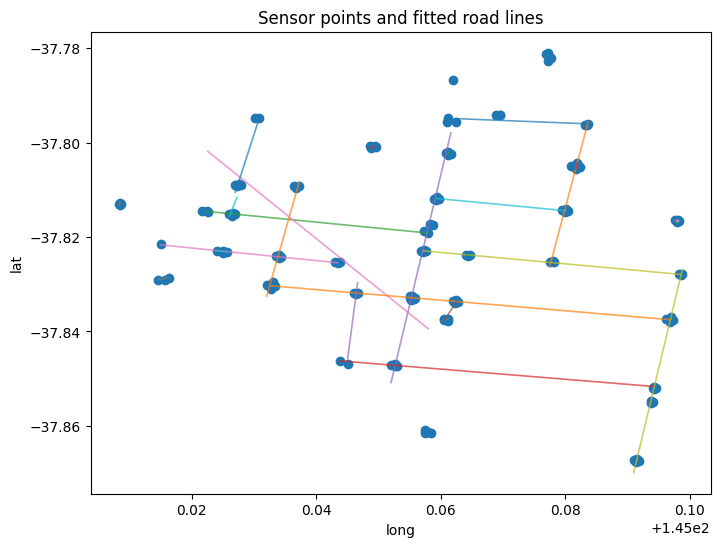

In [19]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

plt.figure(figsize=(8, 6))

# scatter all points first
plt.scatter(df_locations["long"], df_locations["lat"])

for road, group in df_locations.groupby("road"):
    # drop any missing or zero coordinates
    g = group[(group["lat"] != 0) & (group["long"] != 0)]
    if len(g) < 2:
        continue

    # fit line latitude = a * longitude + b
    X = np.array(g["long"].values).reshape(-1, 1)
    y = np.array(g["lat"].values)
    model = LinearRegression().fit(X, y)
    x_line = np.linspace(X.min(), X.max(), 50)
    y_line = model.predict(x_line.reshape(-1, 1))

    # draw road line
    plt.figure
    plt.plot(x_line, y_line, lw=1.2, alpha=0.7, label=road)

plt.xlabel("long")
plt.ylabel("lat")
plt.title("Sensor points and fitted road lines")
# plt.legend()
plt.show()


Now for actual functionality. 

My teacher said that she wants an "adjacency graph". However, for the life of me, I can't find anything like that. However, we can determine something *approximately* approximately like that via our friend k-Nearest Neighbors!

In [11]:
from sklearn.metrics import pairwise_distances

coordinates = df_locations[["lat", "long"]].to_numpy().astype(np.float64)
print(pairwise_distances(coordinates, metric="haversine"))


[[0.         0.00054393 0.00058423 ... 0.09859992 0.09853288 0.09880458]
 [0.00054393 0.         0.00047788 ... 0.09886853 0.09880017 0.09907292]
 [0.00058423 0.00047788 0.         ... 0.09839673 0.09832816 0.09860108]
 ...
 [0.09859992 0.09886853 0.09839673 ... 0.         0.00028219 0.00021201]
 [0.09853288 0.09880017 0.09832816 ... 0.00028219 0.         0.00034903]
 [0.09880458 0.09907292 0.09860108 ... 0.00021201 0.00034903 0.        ]]


In [12]:
import numpy as np

# pairwise_distances returns radians for 'haversine', multiply by Earth's radius to get km
earth_radius = 6371.0
dist_km = pairwise_distances(coordinates, metric='haversine') * earth_radius

# sigma can be mean or median of nonzero distances
sigma = np.mean(dist_km[dist_km > 0])

# weight matrix: exponential decay
W = np.exp(-dist_km**2 / (2 * sigma**2))

# optional: zero out self-loop if you want
np.fill_diagonal(W, 0)

print(W.shape)  # (137, 137)
W

(136, 136)


array([[0.        , 0.99990543, 0.99989089, ..., 0.04469703, 0.04488627,
        0.04412348],
       [0.99990543, 0.        , 0.999927  , ..., 0.04394553, 0.04413577,
        0.04338084],
       [0.99989089, 0.999927  , 0.        , ..., 0.04527264, 0.04546829,
        0.04469377],
       ...,
       [0.04469703, 0.04394553, 0.04527264, ..., 0.        , 0.99997454,
        0.99998563],
       [0.04488627, 0.04413577, 0.04546829, ..., 0.99997454, 0.        ,
        0.99996106],
       [0.04412348, 0.04338084, 0.04469377, ..., 0.99998563, 0.99996106,
        0.        ]], shape=(136, 136))